## Imports

In [1]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import os
from zipfile import ZipFile

from models import get_model
from trainers import get_trainer
from evaluation import *
from data import Augmentor

## Constants/Config

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
DATA_ZIP_PATH = "./datasets/CDNet"
DATASET_NAME = "highway"
DIMS = (128, 128)

DATASET_PATH = os.path.join(DATA_ZIP_PATH, DATASET_NAME)
print(f"Using device: {DEVICE}\n")
print(torch.version.cuda)

Using device: cuda

13.0


## Download data

In [3]:
if os.path.exists(DATA_ZIP_PATH) is False:
    with ZipFile(f"{DATA_ZIP_PATH}.zip", 'r') as zip:
        zip.extractall("./datasets/")

# TODO: fix data format in the zip

Initialized Augmentor with source: ./datasets/CDNet\highway, initial dimensions: (240, 320)
Identity augmentation requested. Using raw source: ./datasets/CDNet\highway
Loaded Flat Dataset: 1700 images from 'input'.
Visualizing images from local index 0...


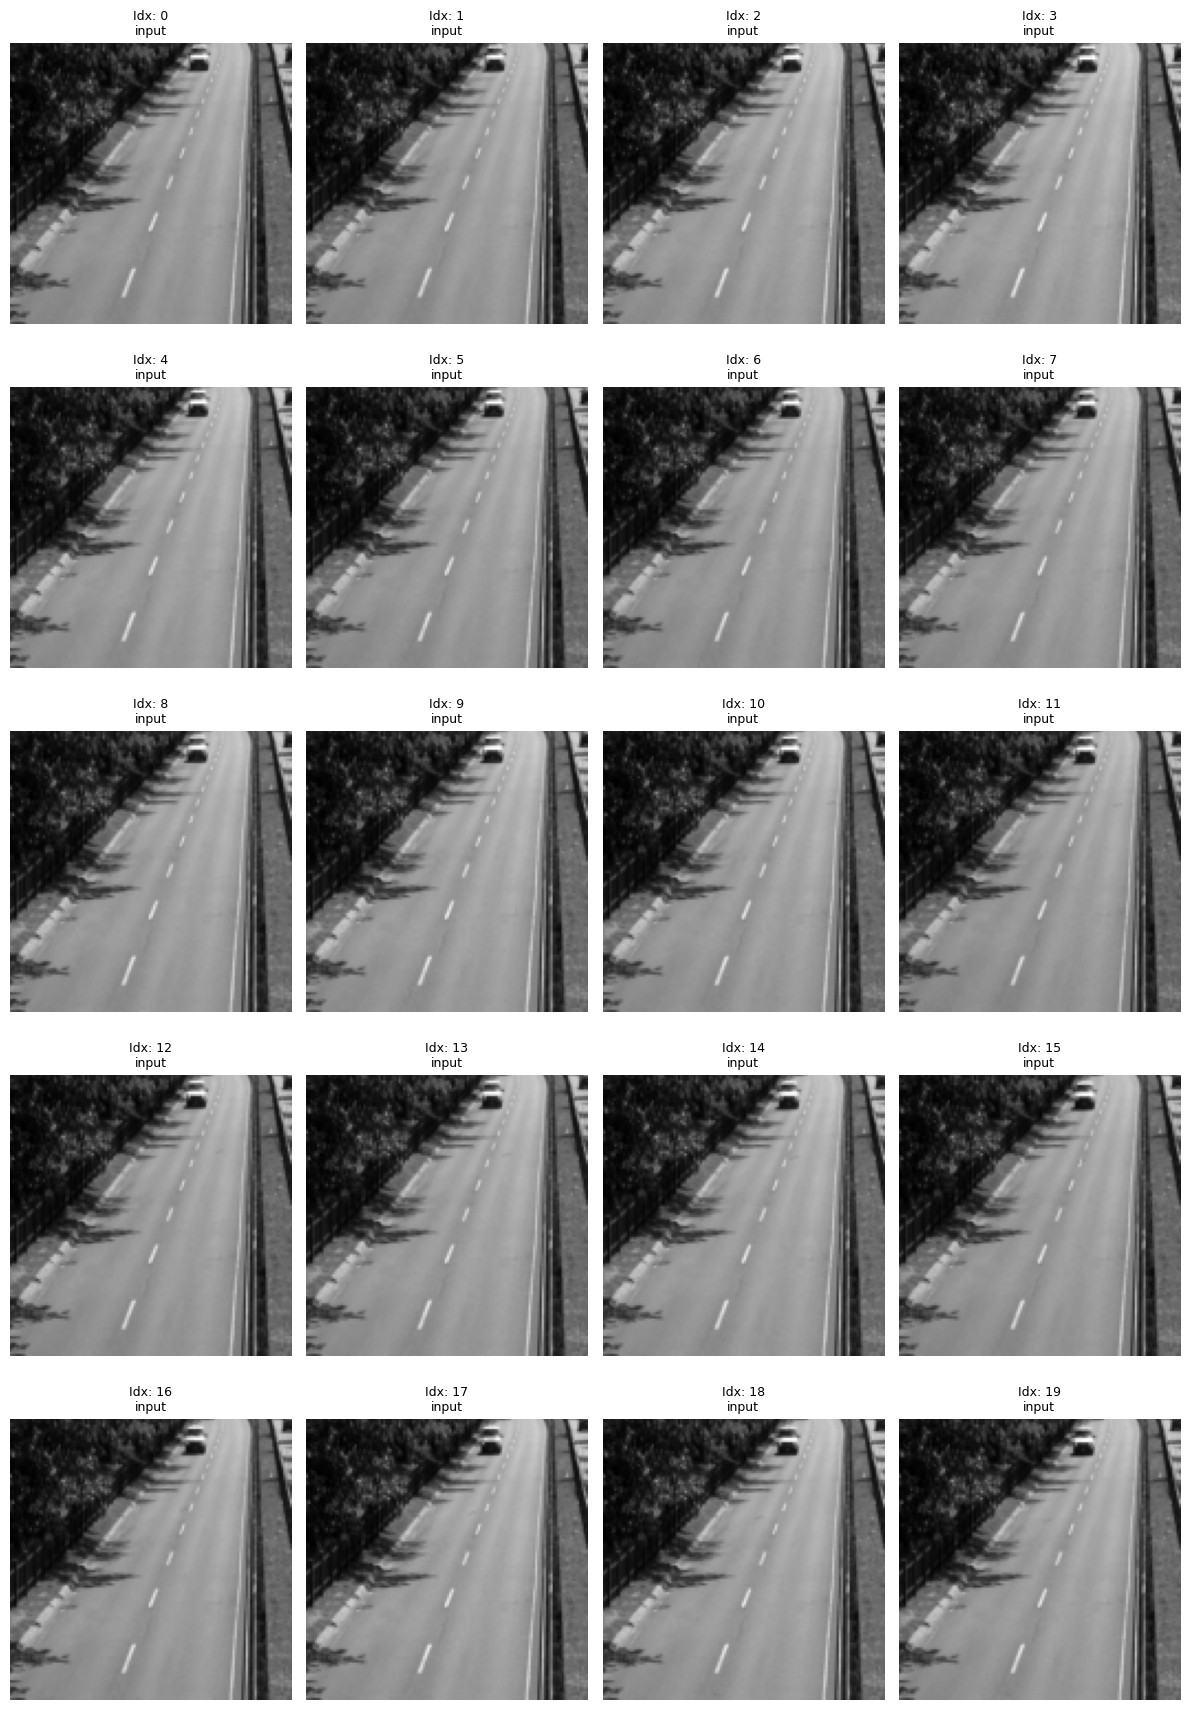

In [4]:
aug = Augmentor(rotation=0, tps=0, elastic=0, source_root=DATASET_PATH, device=DEVICE)
# aug.prepare(force_rebuild=True)

# input_shape = (max(aug.init_dims), max(aug.init_dims))
i2r_data = aug.get_dataset(
    transform=transforms.Compose([
        transforms.Resize(DIMS),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()
    ])
)

i2r_loader = DataLoader(i2r_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(i2r_data, batch_size=len(i2r_data), shuffle=False, num_workers=0)

i2r_data.visualize(num_images=20)

In [5]:
rda_params = {
        'latent_dim': 16,
        'dropout': 0.33,
        'std': 0.5,
        'lr': 2e-4,
        'lambda_': 0.003,
        'outer_epochs': 2,
        'inner_epochs': 15,
    }

Using parameters: {'latent_dim': 16, 'dropout': 0.33, 'std': 0.5, 'lr': 0.0002, 'lambda_': 0.003, 'outer_epochs': 2, 'inner_epochs': 15}

Trainer loaded to cuda:0

Training with ADMM Algorithm (l1 norm)...


ADMM Steps:   0%|          | 0/2 [00:00<?, ?it/s]

Step 1: Training AE:   0%|          | 0/15 [00:00<?, ?it/s]

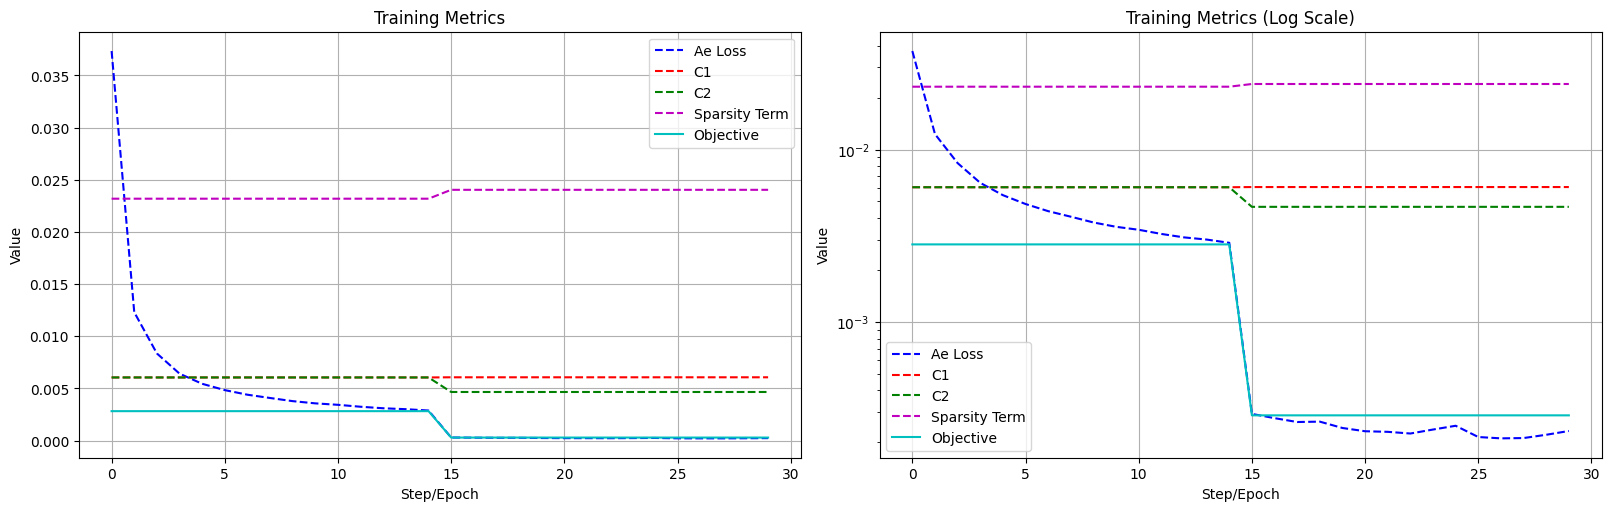

Step 2: Training AE:   0%|          | 0/15 [00:00<?, ?it/s]

Final Reconstruction Loss: 2.3285e-04
ADMM Training Complete.


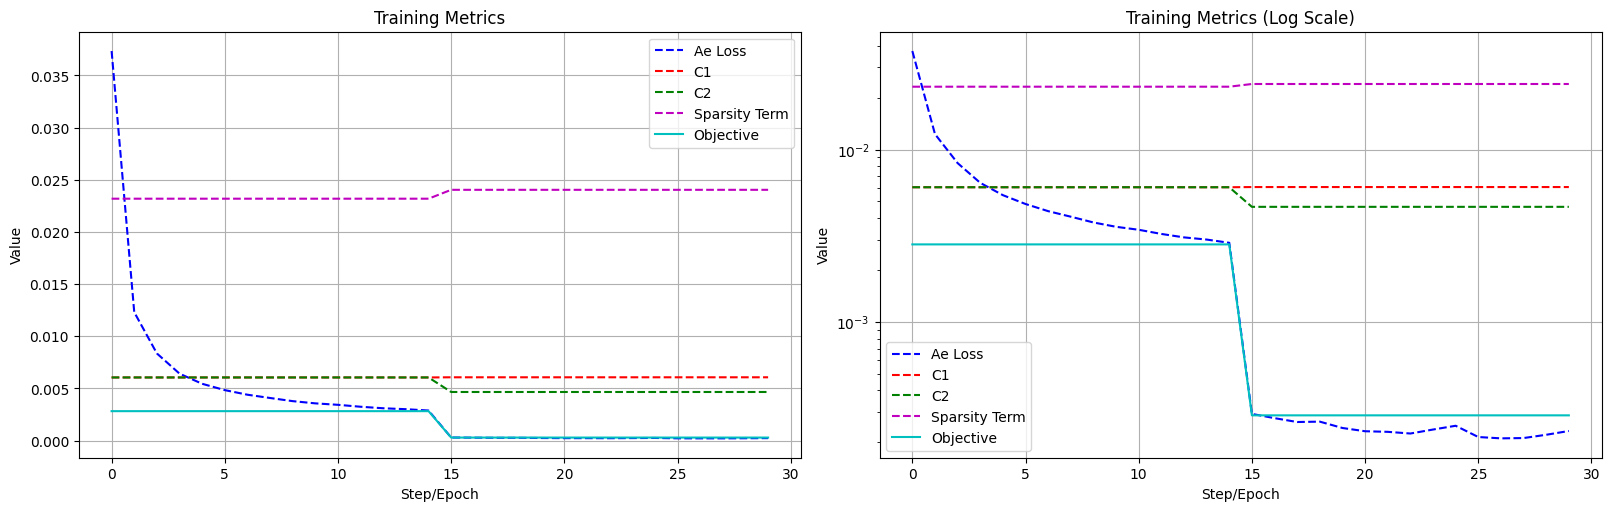

In [6]:
models_dict = {}

rpca = get_model('RPCA', max_iter=6000, lambda_=None, tol=1e-7).to(DEVICE)
rda = get_model('RDA', input_shape=DIMS, latent_dim=rda_params['latent_dim'], dropout=rda_params['dropout'], std=rda_params['std']).to(DEVICE)

print(f"Using parameters: {rda_params}\n")

trainer = get_trainer('RDA', rda, i2r_loader)

trainer.fit(
        outer_epochs=rda_params['outer_epochs'], 
        inner_epochs=rda_params['inner_epochs'],
        lr=rda_params['lr'],
        lambda_=rda_params['lambda_']
    )
    
models_dict['RDA'] = rda

# unload from gpu to save memory for evaluation
# models_dict['RDA'] = models_dict['RDA'].cpu()

In [7]:
print( os.path.abspath(f"./results/{aug.dest_root.split('/')[-1]}/"))

c:\Users\joshu\repos\P114-Annotation-Free-Segmentation\results\CDNet\highway


In [8]:
for model in models_dict.values():
    model.eval()
  
batch = next(iter(test_loader))
X_input, _, _ = batch 

print(f"\nEvaluating on batch of size {X_input.shape[0]}...")
results_root = os.path.abspath(f"./results/{aug.dest_root.split('/')[-1]}/")

X_resized, L_rpca, S_rpca = get_rpca_decomposition(X_input, rpca, results_root, force_recompute=False,target_size=aug.init_dims)
model_results = run_deep_models_inference(X_input, models_dict, target_size=aug.init_dims)



Evaluating on batch of size 1700...
Found pre-computed RPCA results. Loading from disk...
Running Deep Models Inference...
Inference done.



In [9]:
truth = aug.get_gc_images()
# visualise_results(X_resized, L_rpca, S_rpca, model_results, truth)
start = 660
end = 760
visualise_results(
    X_resized[start:end], 
    L_rpca[start:end], 
    S_rpca[start:end], 
    {name: (L[start:end], S[start:end]) for name, (L, S) in model_results.items()}, 
    truth[start:end] if truth is not None else None
)


In [10]:
if truth is not None:
    dice_scores = []
    for name, (L, S) in model_results.items():
        dice = calculate_dice(truth, S)
        dice_scores.append((name, dice))
        print(f"Dice Score for {name}: {dice}")

Dice Score for RDA: 0.5471472144126892


In [11]:
print("Do you want to save the trained Autoencoder model? (y/n): ", end="")
save_choice = input().strip().lower()
if save_choice == 'y':
    model_name = "rda_model_i2r_3"
    torch.save(rda.state_dict(), f"{model_name}.pth")
    print(f"Model saved as {model_name}.pth")
else:
    print("Model not saved.")

Do you want to save the trained Autoencoder model? (y/n): Model not saved.
